# 4.1. Creación de la señal

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros dados en el enunciado
F0 = 0.01   # Frecuencia de la señal (Hz)
Fs = 25 # Frecuencia de muestreo (Hz)
n = np.arange(0, 1000)  # Índices de tiempo (0 a 1000 muestras)
alpha = 0.8 # Atenuación
D = 15  # Retardo en muestras que se está asumiento
varianza = 0.1   # Varianza del ruido gaussiano


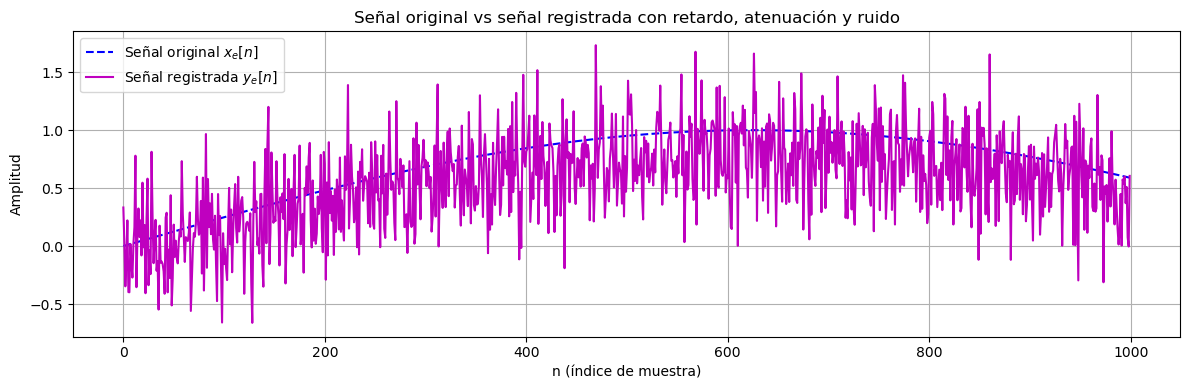

In [2]:
# Señal original xe[n]
xe = np.sin(2 * np.pi * F0 * n / Fs)    # sen(2*pi*(Fo*n/Fs)) representa una señal limpia, sin ruido

# Retardo de D muestras
xe_retrasada = np.concatenate((np.zeros(D), xe[:-D]))   # Añadimos ceros al inicio y cortamos la señal al final para que quede del mismo largo

# Ruido w[n]
ruido = np.random.normal(loc=0, scale=np.sqrt(varianza), size=len(xe))  # loc=0 es la medida centrada en cero

# Señal registrada ye[n] = α * xe[n - D] + w[n]
ye = alpha * xe_retrasada + ruido

# Graficar ambas señales
plt.figure(figsize=(12, 4))
plt.plot(n, xe, label='Señal original $x_e[n]$', linestyle='--', color='b')
plt.plot(n, ye, label='Señal registrada $y_e[n]$', color='m')
plt.xlabel('n (índice de muestra)')
plt.ylabel('Amplitud')
plt.title('Señal original vs señal registrada con retardo, atenuación y ruido')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4.2. Diseño de un filtro

In [3]:
from scipy.signal import firwin, freqz
import matplotlib.pyplot as plt

# Parámetros 
nyq = Fs / 2        # Frecuencia de Nyquist
orden = 30

# Frecuencias de corte en Hz
fc_pb = 1.25        # pasa bajas
fc_pa = 7.5         # pasa altas
fc1_pbanda = 1.25   # límite inferior pasa banda
fc2_pbanda = 7.5    # límite superior pasa banda


Realizamos el diseño del filtro FIR

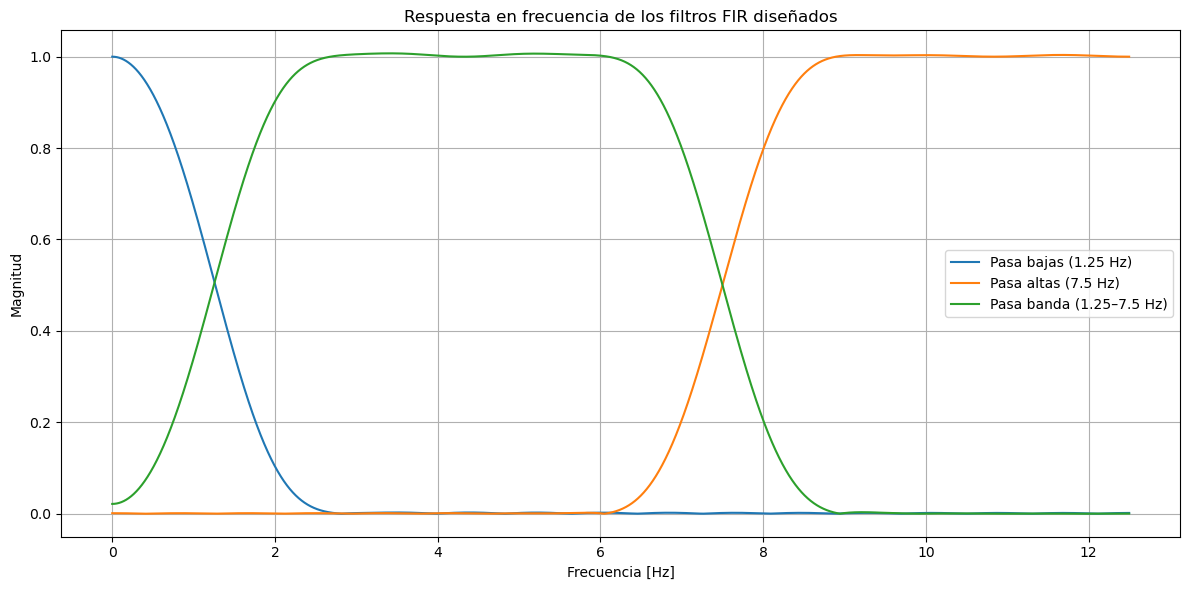

In [4]:
# Diseño de filtros FIR
filtro_pb = firwin(orden + 1, fc_pb / nyq, pass_zero=True)  # Pasa bajas
filtro_pa = firwin(orden + 1, fc_pa / nyq, pass_zero=False) # Pasa altas
filtro_pbanda = firwin(orden + 1, [fc1_pbanda / nyq, fc2_pbanda / nyq], pass_zero=False)  # Pasa banda

# Visualizamos la respuesta en frecuencia
plt.figure(figsize=(12, 6))

for i, (h, nombre) in enumerate(zip([filtro_pb, filtro_pa, filtro_pbanda], 
                                    ['Pasa bajas (1.25 Hz)', 'Pasa altas (7.5 Hz)', 'Pasa banda (1.25–7.5 Hz)'])):
    w, response = freqz(h, worN=8000)
    freq = w * Fs / (2 * np.pi)  # Escala de frecuencia en Hz
    plt.plot(freq, abs(response), label=nombre)

plt.title('Respuesta en frecuencia de los filtros FIR diseñados')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*¿Qué cambios hay en los argumentos de la función firwin para implementar un filtro pasa banda y pasa altas?*
La función firwin cambia según el tipo de filtro con el argumento pass_zero:
- Pasa bajas: firwin(N, Wn, pass_zero=True)
- Pasa altas: firwin(N, Wn, pass_zero=False)
- Pasa banda: firwin(N, [Wn1, Wn2], pass_zero=False)

Ahora el diseño del filtro IIR

In [5]:
from scipy.signal import iirfilter

# Parámetros comunes
orden_iir = 4
fs = 25
nyq = fs / 2

# Frecuencias de corte normalizadas
fc_pb = 1.25 / nyq
fc_pa = 7.5 / nyq
fc_banda = [1.25 / nyq, 7.5 / nyq]

# Diseño de filtros IIR (Butterworth)
b_pb, a_pb = iirfilter(orden_iir, Wn=fc_pb, btype='low', ftype='butter')
b_pa, a_pa = iirfilter(orden_iir, Wn=fc_pa, btype='high', ftype='butter')
b_banda, a_banda = iirfilter(orden_iir, Wn=fc_banda, btype='band', ftype='butter')


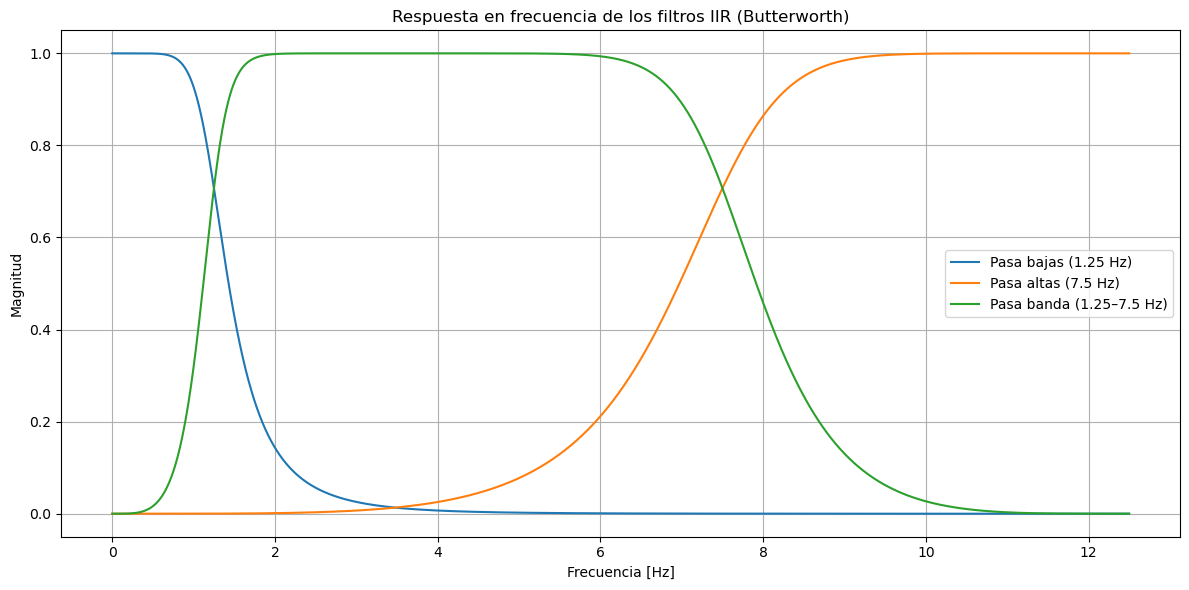

In [6]:
# Ahora graficamos la señal
plt.figure(figsize=(12, 6))

filtros_iir = [
    (b_pb, a_pb, 'Pasa bajas (1.25 Hz)'),
    (b_pa, a_pa, 'Pasa altas (7.5 Hz)'),
    (b_banda, a_banda, 'Pasa banda (1.25–7.5 Hz)')
]

for b, a, nombre in filtros_iir:
    w, h = freqz(b, a, worN=8000)
    freqs = w * fs / (2 * np.pi)
    plt.plot(freqs, abs(h), label=nombre)

plt.title('Respuesta en frecuencia de los filtros IIR (Butterworth)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*Comparación de ambos filtros:*

Se puede observar que a pesar de que el orden en el filtro FIR es mayor, éste tiene una banda de transición más lenta (la pendiente es menos pronunciada), por el contrario el filtro IIR tiene un orden mucho menor, con una atenuación mas rápida

Por otro lado, en el caso del filtro IIR como se está utilizando un filtro Butterworth, éste es conocido por tener una respuesta plana en la banda pasante, lo cual es observado en el gráfico de los filtros IIR. En el caso del filtro FIR, no se observa una respuesta plana en la banda pasante, sin embargo, no tiene un rizado alto, la repsuesta es suave.

# 4.3. Filtrado

### Primero realizamos el filtrado con ambas funciones del filtro FIR

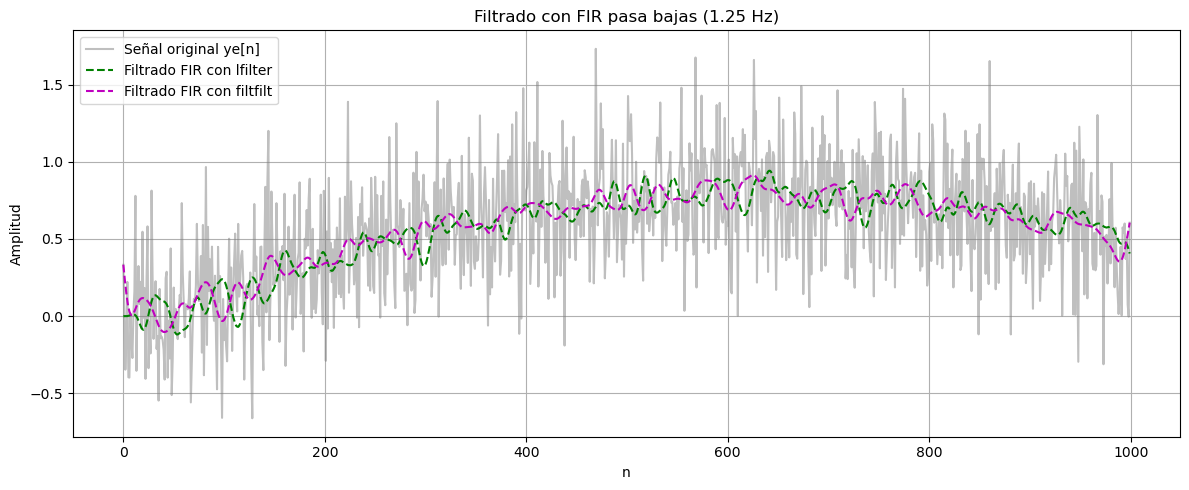

In [7]:
from scipy.signal import lfilter, filtfilt

# Filtrado FIR con lfilter
ye_lfilter_fir = lfilter(filtro_pb, 1, ye) 
ye_filtfilt_fir = filtfilt(filtro_pb, 1, ye)

# Graficar comparación
plt.figure(figsize=(12, 5))
plt.plot(n, ye, label='Señal original ye[n]', color='gray', alpha=0.5)
plt.plot(n, ye_lfilter_fir, label='Filtrado FIR con lfilter', color='g', linestyle='--')
plt.plot(n, ye_filtfilt_fir, label='Filtrado FIR con filtfilt', color='m', linestyle='--')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.title('Filtrado con FIR pasa bajas (1.25 Hz)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Se puede observar que en ambos casos la señal es filtrada correctamente en ambos casos (utilizando ambas funciones). Sin embargo, vemos que con la función lfilter la señal tiene un pequeño desfase, introduce un retardo; mientras que la señal filtrada con la función filtfilter no presenta un retardo.

*Solución a las preguntas:*

* **¿Por qué se utiliza sólo el numerador? ¿A qué hace referencia el numerador?:** En general, los coeficientes del numerador hacen referencia a la entrada de la señal, y los coeficientes del denominador a la salida de la señal, por lo que se necesitará de valores pasados de la señal. En este caso, el filtro FIR no requiere de valores pasados de la señal, por lo cual el denominador será igual a 1. Como los filtros FIR siempre son estables, no se requiere de retroalimentación (valores pasados de la señal).

* **¿Evidencia cambios en el uso de las funciones de filtrado? ¿Cómo se puede explicar la falta de coincidencia?:** Sí, se observa que con el uso de la función lfilter se introduce un retardo en la señal, la función lfilter es causal por lo que produce retardo. En el caso de la funcion filtfilter, es una función no causal, y como utiliza un filtrado hacia adelante y hacia atrás, elimina el retardo.

* **¿Es adecuado el orden del filtro usado?:** Sí, se logra observar que con un orden 30 se reduce el ruido sin distorcionar mucho la señal, esta sigue la misma trayectoria y disminuye el ruido.

### Ahora realizamos el filtro IIR utilizando ambas funciones

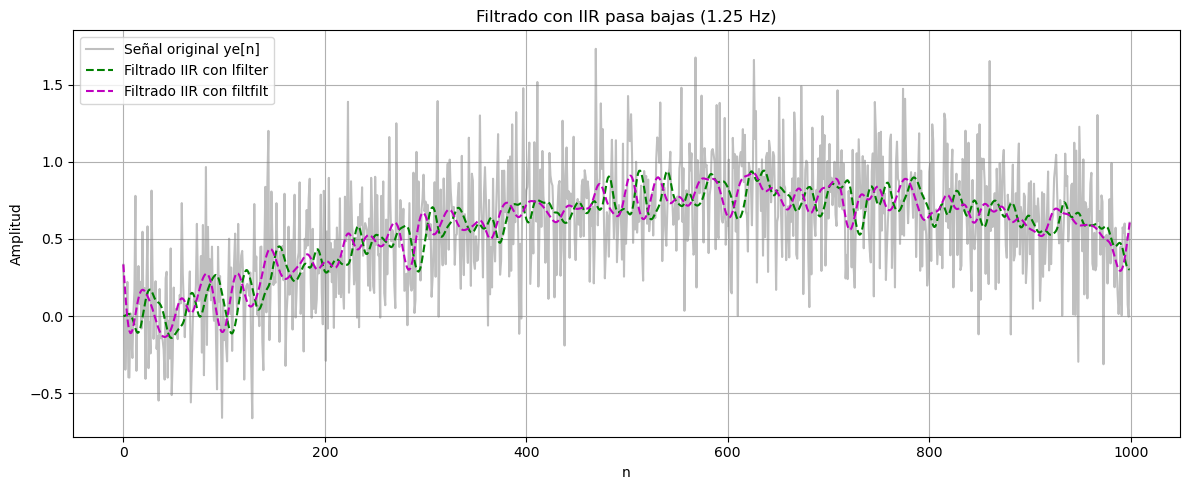

In [8]:
# Aplicamos el filtro IIR pasa bajas con lfilter
ye_lfilter_iir = lfilter(b_pb, a_pb, ye)

# Aplicamos el filtro IIR pasa bajas con filtfilt
ye_filtfilt_iir = filtfilt(b_pb, a_pb, ye)

# Graficar resultados
plt.figure(figsize=(12, 5))
plt.plot(n, ye, label='Señal original ye[n]', color='gray', alpha=0.5)
plt.plot(n, ye_lfilter_iir, label='Filtrado IIR con lfilter', linestyle='--', color='g')
plt.plot(n, ye_filtfilt_iir, label='Filtrado IIR con filtfilt', linestyle='--', color='m')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.title('Filtrado con IIR pasa bajas (1.25 Hz)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Al igual que en el caso del filtro FIR, se observa que la señal filtrada correctamente, pues disminuye en ambos casos el ruido, siguiendo la trayectoria de la señal, sin distorcionarla. Sin embargo, al igual que con el filtro FIR, la señal utilizada con la función lfilter tiene un retraso

*Solución a las preguntas:*

* **¿Por qué se utiliza numerador y denominador?:** Como se explicó en el caso del filtro FIR, los coeficientes del numerador hacen referencia a la entrada de la señal, y los coeficientes del denominador a la salida de la señal, por lo que se necesitará de valores pasados de la señal. En este caso, el filtro IIR sí requiere de valores pasados de la señal, por lo cual es necesario utilizar el denominador, el cual sirve como retroalimentación a la señal


* **¿Es necesario cambiar el orden del filtro?:** No es necesario, se puede observar que la señal es filtrada correctamente. En ambos casos se atenúa el fuido sin perder la forma de la señal.

# 4.4 Aplicación

Cargue la señal señal_filtros.txt adquirida a una frecuencia de muestreo de 500 Hz. Extraiga y trabaje con el canal 1 de la señal.

Se encontraron 1 archivos.
./senal_filtros.txt


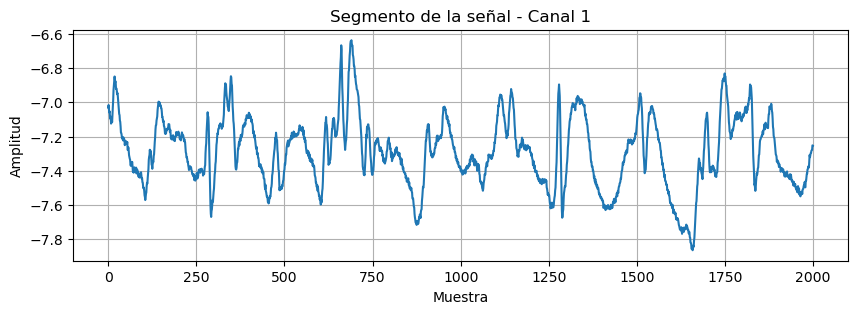

In [ ]:

from scipy.signal import welch
import glob

# Ruta al archivo 

RUTA = "./senal_filtros.txt" 
archivos = glob.glob(RUTA)
print(f"Se encontraron {len(archivos)} archivos.")
for archivo in archivos:
    print(archivo)

# Cargar el archivo de texto
datos = np.loadtxt(RUTA)

# Extraer canal 1 (columna 0)
canal_1 = datos[:, 0]
fs = 500  # Frecuencia de muestreo

# Visualizar una parte de la señal
plt.figure(figsize=(10, 3))
plt.plot(canal_1[:2000])  # Primeros 4 segundos aprox
plt.title("Segmento de la señal - Canal 1")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


Realice un análisis frecuencial con la función que permite calcular el periodograma de Welch de una señal ¿Hay presencia de ruido eléctrico? Analice.

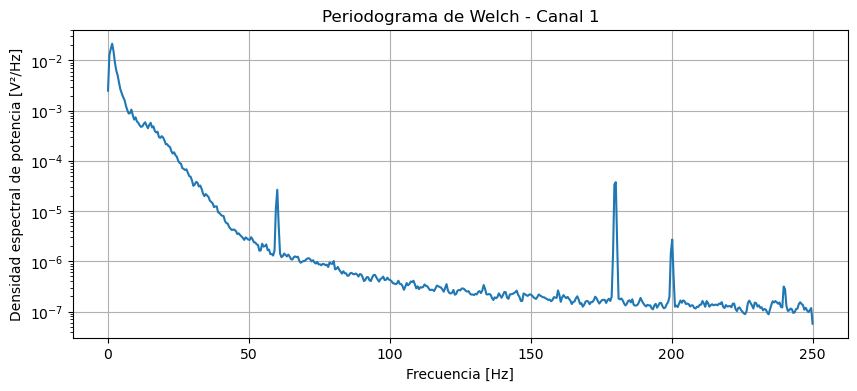

In [19]:
# Calcular el periodograma de Welch
frecuencias, psd = welch(canal_1, fs=fs, nperseg=1024)

# Graficar
plt.figure(figsize=(10, 4))
plt.semilogy(frecuencias, psd)
plt.title("Periodograma de Welch - Canal 1")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [V²/Hz]")
plt.grid(True)
plt.show()

Tras la carga de la señal del canal 1 y su análisis espectral utilizando el método del periodograma de Welch, se observa un comportamiento típico de una señal biológica contaminada por artefactos eléctricos. La estimación espectral revela un pico muy pronunciado en la banda de 50 Hz, lo cual es un fuerte indicativo de la presencia de ruido de red eléctrica. Adicionalmente, se observan otros picos de menor magnitud alrededor de los 200 Hz, posiblemente relacionados con armónicos de la señal principal de 50 Hz, lo cual refuerza la hipótesis de una contaminación sistemática de origen eléctrico. Este patrón es característico de los armónicos generados por equipos electrónicos que operan a la misma frecuencia de red. Por tanto, y dada la naturaleza del ruido identificado, se hace necesario aplicar técnicas de filtrado digital, específicamente el diseño de un filtro tipo pasa banda que permita conservar únicamente las frecuencias fisiológicas de interés (por ejemplo, entre 0.5 y 40 Hz), eliminando así tanto el ruido de red como sus posibles armónicos.

Diseñe un filtro FIR que permita eliminar el ruido de la señal. Grafique. Luego verifique nuevamente el comportamiento en frecuencia (periodograma de Welch de la señal filtrada) ¿Hay cambios? Analice.

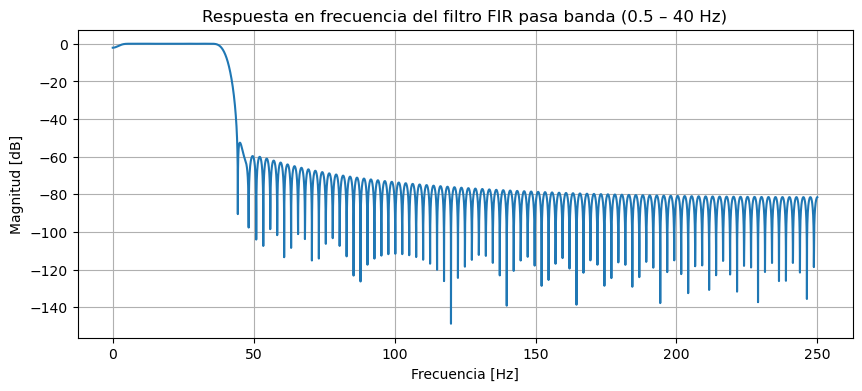

In [ ]:
from scipy.signal import firwin, filtfilt, freqz

# Frecuencias normalizadas
nyq = fs / 2
low_cut = 0.5 / nyq
high_cut = 40 / nyq

# Diseño del filtro FIR pasa banda
orden = 201  # Cuanto más alto, mejor respuesta en frecuencia 
filtro_fir = firwin(numtaps=orden, cutoff=[low_cut, high_cut], pass_zero=False)

# Visualizar la respuesta en frecuencia del filtro
w, h = freqz(filtro_fir, worN=8000)
plt.figure(figsize=(10, 4))
plt.plot(w * nyq / np.pi, 20 * np.log10(np.abs(h)))
plt.title("Respuesta en frecuencia del filtro FIR pasa banda (0.5 – 40 Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid(True)
plt.show()

En la región entre 0.5 Hz y 40 Hz, se observa una respuesta relativamente plana en magnitud (alrededor de 0 dB), lo cual indica que el filtro preserva adecuadamente estas frecuencias, evitando atenuaciones indeseadas. Esta banda coincide con la mayor parte de la actividad biológica significativa en señales electrofisiológicas.

A partir de los 40 Hz, la respuesta cae abruptamente, alcanzando atenuaciones mayores a 60 dB, lo que indica que las frecuencias fuera de la banda de interés incluyendo el pico de 50 Hz característico del ruido eléctrico de red serán fuertemente atenuadas.  Además, la respuesta muestra una transición suave y controlada, típica de los filtros FIR, lo que garantiza una fase lineal y evita distorsión temporal en la forma de onda.

El filtro cumple adecuadamente su función: preserva las frecuencias fisiológicas (0.5–40 Hz) y elimina tanto el ruido de red (50 Hz) como componentes de alta frecuencia, con una respuesta estable y predecible. Esto lo hace ideal para la siguiente etapa, donde aplicaremos el filtrado sobre la señal original.

Grafique un segmento de las señales antes y después de filtrar, analice los cambios.

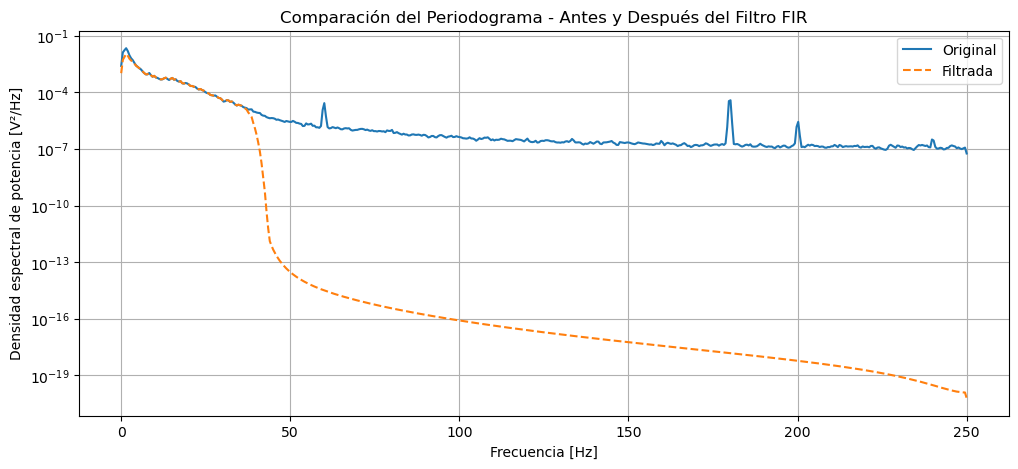

In [21]:
# Aplicar el filtro usando filtfilt para evitar fase no lineal
canal_filtrado = filtfilt(filtro_fir, 1, canal_1)

# Calcular el nuevo periodograma de Welch
frecs_filtrado, psd_filtrado = welch(canal_filtrado, fs=fs, nperseg=1024)

# Graficar antes vs después
plt.figure(figsize=(12, 5))
plt.semilogy(frecuencias, psd, label="Original")
plt.semilogy(frecs_filtrado, psd_filtrado, label="Filtrada", linestyle='--')
plt.title("Comparación del Periodograma - Antes y Después del Filtro FIR")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [V²/Hz]")
plt.legend()
plt.grid(True)
plt.show()


En la señal original, persiste un pico prominente en 50 Hz, correspondiente al ruido eléctrico de red, así como otras componentes de alta frecuencia visibles en torno a 200 Hz, posiblemente armónicos. Estas componentes son indeseadas en el análisis de señales biológicas, ya que no corresponden a información fisiológica relevante y pueden interferir con la detección de eventos como picos R o actividad muscular.

Una vez aplicado el filtro FIR con banda de paso entre 0.5 Hz y 40 Hz, se observa una atenuación drástica de todas las frecuencias fuera de este rango. En particular:

El pico en 50 Hz ha sido completamente eliminado.

Las componentes superiores a 40 Hz presentan una caída de energía de varios órdenes de magnitud (hasta 10⁻¹⁹), lo cual demuestra la eficacia del filtro.

La banda fisiológica entre 0.5 y 40 Hz se mantiene preservada, sin distorsiones aparentes.

Este comportamiento confirma que el filtro diseñado es eficaz para limpiar la señal, mejorando así su calidad para posteriores análisis clínicos o computacionales.

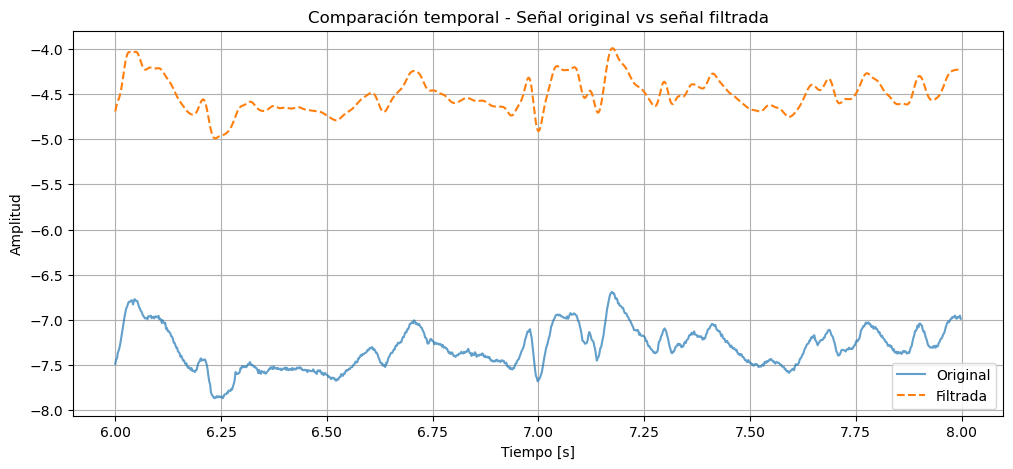

In [22]:
# Seleccionar un segmento de 2 segundos (1000 muestras si fs = 500 Hz)
inicio = 3000
fin = inicio + 1000

tiempo = np.arange(inicio, fin) / fs

# Graficar
plt.figure(figsize=(12, 5))
plt.plot(tiempo, canal_1[inicio:fin], label='Original', alpha=0.7)
plt.plot(tiempo, canal_filtrado[inicio:fin], label='Filtrada', linestyle='--')
plt.title("Comparación temporal - Señal original vs señal filtrada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

La señal original presenta oscilaciones rápidas y una forma de onda irregular, lo cual es indicativo de la presencia de componentes de alta frecuencia y ruido eléctrico de 50 Hz, previamente identificado en el análisis espectral. Después de aplicar el filtro FIR pasa banda, la señal filtrada muestra un comportamiento más suavizado, con menos fluctuaciones rápidas, preservando las tendencias de baja frecuencia que corresponden con mayor probabilidad a la actividad biológica real. La forma de onda es más clara y con contornos más definidos, lo cual facilita la identificación de eventos relevantes y permite un análisis más confiable.

Aunque el nivel de amplitud ha cambiado, esto es esperable tras un filtrado pasa banda que remueve componentes que pueden haber influido en la energía total de la señal. Lo más importante es que la forma general se conserva, sin introducir distorsiones ni retrasos gracias al uso de la función filtfilt, que garantiza un filtrado sin desfase.

En conclusión, el filtrado permitió mejorar la calidad de la señal biológica, reduciendo el ruido de red eléctrica y eliminando componentes de alta frecuencia no fisiológicas, sin comprometer la información clínica esencial de la señal.